# Uczenie głębokie 


## laboratorium: GNN

Najważniejsze koncepcje :
-   modele grafowe
-   model z instrukcjami kontrolnymi



In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [2]:
import keras
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Dane

Jako dane do treningu wykorzystamy analityczny model sieci z teorii kolejek.

### Cechy wierzchołków

1. Ruch wejściowy
2. Szybkość obsługi (suma podłaczonej przepustowosci)

### Cechy krawedzi

1. Ułamek ruchu węzła poczatkowego przechodzący do węzła docelowego  (ruting)

### Cechy grafu

1. Średnie opóźnienie w sieci

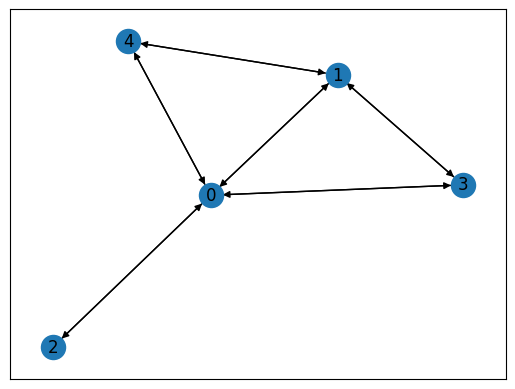

In [3]:
G = nx.barabasi_albert_graph(5, 2)
G = nx.DiGraph(G)
nx.draw_networkx(G)
# A=nx.convert_matrix.to_numpy_matrix(G)
A = nx.to_numpy_array(G)

# Rozgrzewka punkt stały

rozwiazać:

$$\cos(x)=x$$

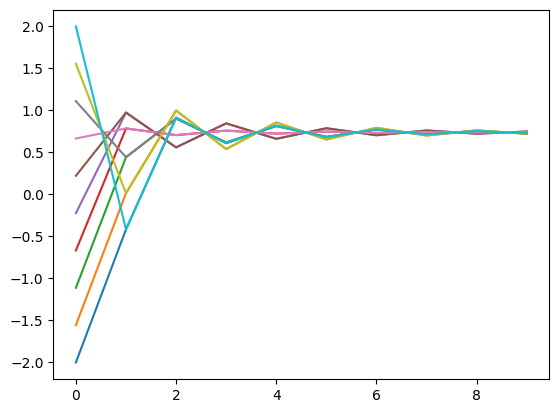

In [6]:
x = np.linspace(-2, 2, 10)
xs = []

for _ in range(10):
    xs.append(x)
    x = np.cos(x)

plt.plot(np.stack(xs, axis=0));

# Parametry

In [7]:
class Args:
    Mhid = 8

    batch_size = 32
    mu_shift = 0.34
    mu_scale = 0.27
    W_shift = 55.3
    W_scale = 22.0
    pad = 8
    pas = 5
    Mhid = 8
    rn = 16
    ninf = 16
    buf = 400
    Nsamples = 10000


args = Args()

N_PAD = args.pad
N_PAS = args.pas
N_H = 2 + N_PAD


### generator danych  syntetycznych

In [8]:
def make_data(A, n, rl, rh):
    # \Lambda
    L = np.random.uniform(size=(A.shape[0], n))
    L = L / np.sum(L, axis=0)
    p = 1.0 / (np.sum(A, axis=1) + 1.0)
    R = np.multiply(A, p)

    lam = np.linalg.solve(np.identity(A.shape[0]) - np.transpose(R), L)
    rho = np.random.uniform(low=rl, high=rh, size=lam.shape)

    mu = lam / rho
    ll = rho / (1 - rho)
    W = np.sum(ll, axis=0) / np.sum(L, axis=0)
    x = np.stack((L, mu), axis=2)
    x = np.transpose(x, [1, 0, 2])
    begin, end = np.nonzero(R)
    e = R[begin, end]
    e = np.tile(e, (n, 1))[..., np.newaxis]
    return x, e, W


In [9]:
rl = 0.2
rh = 0.6


x, e, w = make_data(A, args.Nsamples, 0.2, 0.6)

mx = x.mean()
sx = x.std()
x = (x - mx) / sx

mw = w.mean()
sw = w.std()

w = (w - mw) / sw

x2, e2, w2 = make_data(A, 200, 0.2, 0.6)
x2 = (x2 - mx) / sx
w2 = (w2 - mw) / sw

# Model - MPNN



Poniżej prezentujemy kod implementujący sieć neuronową przekazującą komunikaty. Algorytm został opisany w artykule, tutaj podajemy jedynie jego podstawowy szkic matematyczny. 

Message: $$ \mathbf m_v^{t+1} = \sum_{w\in{N(v)}} M_t\left(\mathbf h_v^t,\mathbf h_w^t,\mathbf e_{vw}\right) \quad t=1,\dots,T,$$

Update: $$\mathbf h_v^{t+1} = U_t\left(\mathbf h_v^t,\mathbf m_v^{t+1}\right) \quad t=0,1,\dots,T,$$

$$\mathbf h_v^0=[\mathbf x_v,0,\ldots, 0]$$

Readout: $$\hat{\mathbf y} = R(\mathbf h)$$

Implementacja `keras`.

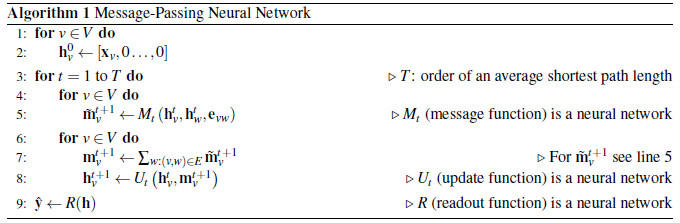

##### Message function

The message function is a neural network parametrized affine function.
We use the SELU activation function because of its good scaling properties.

For more details on `selu`, see for instance paper by Klambauer et al. "Self-Normalizing Neural Networks", 31st Conference on Neural Information Processing Systems NIPS 2017 ([arXiv:1706.02515v5](https://arxiv.org/abs/1706.02515)).

```python
  def _M(self,h,e):
    a = self.l(e)
    m=tf.matmul(a,tf.expand_dims(h,axis=2) )
    m = tf.squeeze(m)
    b = self.b(e)
    return m + b

```

##### Update function

The update function is based on a custom implementation of a GRU (Gated Recurrent Unit) recurrent neural network.
The reason for this is that GRU is simpler in comparison to LSTM (i.e., there is no output gate) and has fewer parameters. This is a recurrent unit that has an internal structure that by design reuses weights (i.e., weight tying) for every element in the sequence. We tried  using different units for subsequent t in the experiments, but the training was much longer without noticeable improvement of accuracy.

For more details on `GRU`, see for instance paper by Chung et al. "Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling", 28th Conference on Neural Information Processing Systems NIPS 2014 ([arXiv:1409.1259v2](https://arxiv.org/pdf/1412.3555.pdf))

```python
  self.u = tf.keras.layers.GRUCell(N_H)

```

##### Readout function

The readout function is obtained just as a neural network with attention.
By 'attention' we mean the mechanism in the neural network allowing it to learn what information is important in a given input. In our readout function, the output of the network $j$ is multiplied with an output of network $i$ processed by the `sigmoid` activation function at the output. The sigmoid function takes values in the range $(0,1)$. Multiplication by such a number acts as a gate selecting the important parts of the output from $j$ for the final summation.


```python
  def _R(self,h,x,segment):
    hx=tf.concat([h,x],axis=1)
    RR = tf.nn.sigmoid(self.i(hx))
    RR = tf.multiply(RR,self.j(hx))
    return tf.math.segment_sum(RR,segment)

```

At this point, the network is represented by a vector. Therefore, we can pass it through a neural network for inference (forward pass).

Below, the main training part is presented. We run message-passing on a graph, then perform the forward pass of the inference and compute $MSE$ loss for the delay. The loss backpropagates and the weights of $M$, $U$, and $R$ networks are updated.

### Implementacja w `keras` 3

In [10]:
import keras.ops as ko
from keras.activations import selu, tanh


class SimpleMessagePassing(keras.layers.Layer):
    def __init__(self, A):
        super(SimpleMessagePassing, self).__init__()
        self.begin, self.end = np.nonzero(A)
        self.num_segments = ko.cast(ko.max(self.end) + 1, "int32")

        self.l = keras.Sequential(
            [
                keras.layers.Dense(args.Mhid, activation=selu),
                keras.layers.Dense(N_H * N_H),
                keras.layers.Reshape((N_H, N_H)),
            ]
        )

        self.b = keras.Sequential(
            [keras.layers.Dense(args.Mhid, activation=selu), keras.layers.Dense(N_H)]
        )

        self.u = keras.layers.GRUCell(N_H)

        self.i = keras.Sequential(
            [keras.layers.Dense(args.rn, activation=tanh), keras.layers.Dense(args.rn)]
        )

        self.j = keras.Sequential(
            [keras.layers.Dense(args.rn, activation=selu), keras.layers.Dense(args.rn)]
        )

    def build(self, input_shape=None):
        self.l.build((None, 1))
        self.b.build((None, 1))
        self.u.build((None, N_H))
        self.i.build((None, N_H + 2))
        self.j.build((None, N_H + 2))

        super(SimpleMessagePassing, self).build(input_shape)

    def call(self, inputs, training=False):
        r = ko.vectorized_map(lambda x: self.call_one(x, training=training), inputs)
        # r = ko.map(lambda x: self.call_one(x, training=training), inputs)
        return ko.sum(r, axis=1)

    def call_one(self, inputs, training=False):
        (x, e) = inputs

        h = ko.pad(x, [[0, 0], [0, N_PAD]])

        for _ in range(N_PAS):
            m = self._M(ko.take(h, self.begin, axis=0), e)
            m = ko.segment_sum(m, self.end, self.num_segments)
            h, _ = self.u(m, [h])
        r = self._R(h, x)
        return r

    def _M(self, h, e):
        a = self.l(e)
        m = ko.matmul(a, ko.expand_dims(h, axis=2))
        m = ko.squeeze(m)
        b = self.b(e)
        return m + b

    def _R(self, h, x):
        hx = ko.concatenate([h, x], axis=1)
        RR = ko.nn.sigmoid(self.i(hx))
        RR = ko.multiply(RR, self.j(hx))
        return RR


In [11]:
xin = keras.layers.Input(x.shape[1:])
ein = keras.layers.Input(e.shape[1:])
h = SimpleMessagePassing(A)((xin, ein))
f = keras.Sequential(
    [keras.layers.Dense(args.ninf, activation=selu), keras.layers.Dense(1)]
)(h)
model = keras.Model(inputs=(xin, ein), outputs=f)
model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), jit_compile=True)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 5, 2)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 12, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ simple_message_passing        │ (None, 16)                │           2,642 │ input_layer[0][0],         │
│ (SimpleMessagePassing)        │                           │                 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_4 (Sequential)     │ (None, 1)                 │             289 │ simple_message_passing[0]… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,931 (11.45 KB)

 Trainable params: 2,931 (11.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
x.shape, e.shape

((10000, 5, 2), (10000, 12, 1))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2853 - val_loss: 0.2560
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1157 - val_loss: 0.0616
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0630 - val_loss: 0.0281
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0259 - val_loss: 0.0327
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - val_loss: 0.0063
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0067 - val_loss: 0.0024
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - val_loss: 0.0028
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - val_loss: 0.0042
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0068 - val_loss: 0.0024
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0067 - val_loss: 0.0029


<Axes: >

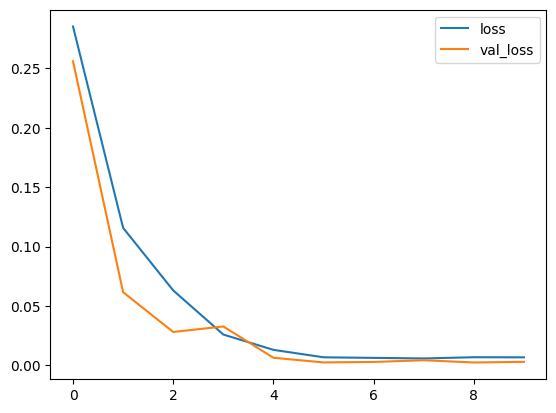

In [13]:
history = model.fit(
    x=(x, e), y=w, epochs=10, batch_size=32, validation_data=((x2, e2), w2)
)
pd.DataFrame(history.history).plot()

# Evaluate


In [14]:
def line_1(x1, x2):
    xmin = np.min(x1.tolist() + x2.tolist())
    xmax = np.max(x1.tolist() + x2.tolist())
    lines = plt.plot([1.1 * xmin, 1.1 * xmax], [1.1 * xmin, 1.1 * xmax])
    return lines


def fitquality(y, f):
    """
    Computes $R^2$
    Args:
        x true label
        f predictions
    """

    ssres = np.sum((y - f) ** 2)
    sstot = np.sum((y - np.mean(y)) ** 2)
    R2 = 1 - ssres / sstot
    print(R2)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


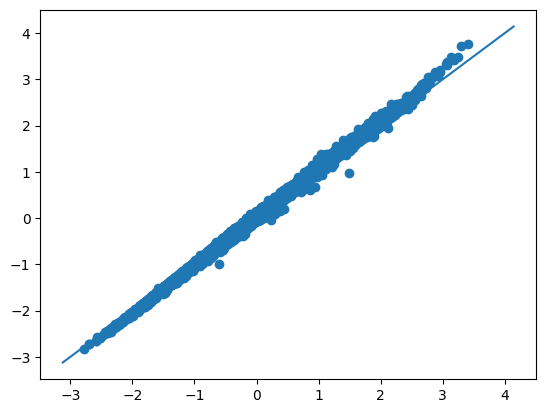

In [15]:
hat = model.predict((x, e))
plt.scatter(hat, w)
line_1(w, hat[:, 0])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


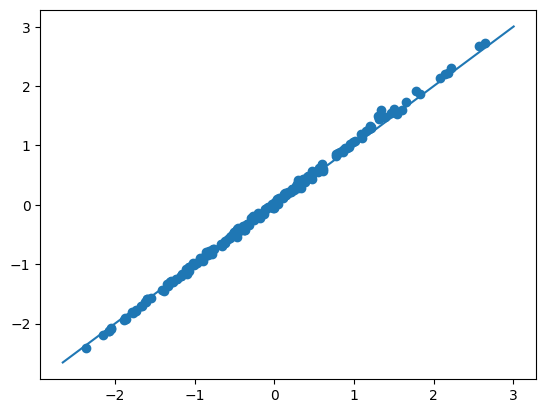

In [16]:
hat2 = model.predict((x2, e2))
plt.scatter(hat2, w2)
line_1(w2, hat2[:, 0])

# Zadanie

Sprawdzić model na innym grafie

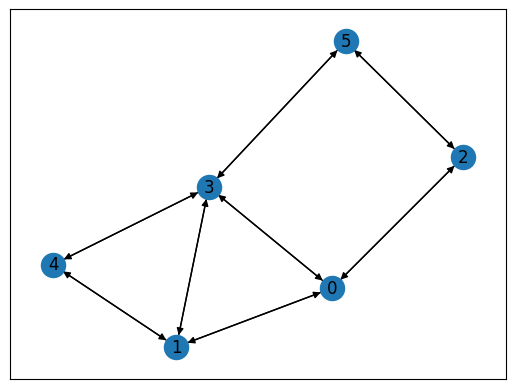

In [17]:
G = nx.barabasi_albert_graph(6, 2)
G = nx.DiGraph(G)
nx.draw_networkx(G)
A = nx.to_numpy_array(G)

x2, e2, w2 = make_data(A, 200, 0.2, 0.6)
x2 = (x2 - mx) / sx
w2 = (w2 - mw) / sw

model.save_weights("model.weights.h5")

In [19]:
# TODO
A_new = A

x_new, e_new, w_new = make_data(A_new, 200, 0.2, 0.6)

x_new = (x_new - mx) / sx
w_new = (w_new - mw) / sw



In [20]:
xin = keras.layers.Input(x_new.shape[1:])
ein = keras.layers.Input(e_new.shape[1:])

h = SimpleMessagePassing(A_new)((xin, ein))

f = keras.Sequential(
    [
        keras.layers.Dense(args.ninf, activation=selu),
        keras.layers.Dense(1),
    ]
)(h)

model_new = keras.Model(inputs=(xin, ein), outputs=f)

In [21]:
model_new.load_weights("model.weights.h5")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step


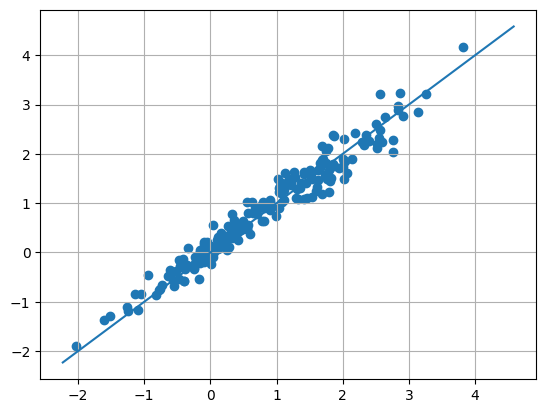

0.950652263251871


In [22]:
hat_new = model_new.predict((x_new, e_new))

plt.scatter(hat_new, w_new)
line_1(w_new, hat_new[:, 0])
plt.grid()
plt.show()

fitquality(w_new, hat_new[:, 0])

# Zadania

1. Przetestuj model dla grafu Barabási-Albert składającego się z 10 wierzchołków z obciążeniami $\leq 0.6$
1. Zobrazuj statystyki treningu i testu
1. Eksperymentuj z różnymi wymiarowościami zanurzeń grafu
1. Model obecny w notebooku jest zaprojektowany dla skomplikowanych problemów grafowych. Spróbuj uprościć model przez:
   - użycie prostej gęstej warstwy jako funkcji `M`
   - użycie gęstej warstwy do aktualizacji (`U`)
   - usunięcie mechanizmu atencji z odczytu



In [38]:

G = nx.barabasi_albert_graph(5, 2)
G = nx.DiGraph(G)
A = nx.to_numpy_array(G)

x, e, w = make_data(A, args.Nsamples, 0.2, 0.6)

mx, sx = x.mean(), x.std()
mw, sw = w.mean(), w.std()

x = (x - mx) / sx
w = (w - mw) / sw

In [40]:
xin = keras.layers.Input(x.shape[1:])
ein = keras.layers.Input(e.shape[1:])

h = SimpleMessagePassing(A)((xin, ein))

f = keras.Sequential(
    [
        keras.layers.Dense(args.ninf, activation=selu),
        keras.layers.Dense(1),
    ]
)(h)

model = keras.Model(inputs=(xin, ein), outputs=f)

model.compile(
    loss="mse",
    optimizer=keras.optimizers.Adam(0.01),
)

model.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_49 (InputLayer)   │ (None, 5, 2)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_50 (InputLayer)   │ (None, 12, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ simple_message_passing_8      │ (None, 16)                │           1,100 │ input_layer_49[0][0],      │
│ (SimpleMessagePassing)        │                           │                 │ input_layer_50[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_40 (Sequential)    │ (None, 1)                 │             289 │ simple_message_passing_8[… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,389 (5.43 KB)

 Trainable params: 1,389 (5.43 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    (x, e),
    w,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 200ms/step - loss: 0.2847 - val_loss: 0.1434
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - loss: 0.1390 - val_loss: 0.1224
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0540 - val_loss: 0.0310
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0210 - val_loss: 0.0141
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0144 - val_loss: 0.0126
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0155 - val_loss: 0.0070
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0049 - val_loss: 0.0025
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0040 - val_loss: 0.0088


In [44]:
pads = [2, 4, 8]

results = []

for p in pads:
    print(f"\nPAD = {p}")
    
    args.pad = p
    N_PAD = p
    N_H = 2 + N_PAD

    # ⚠️ NOWA WARSTWA + NOWY MODEL
    xin = keras.layers.Input(x.shape[1:])
    ein = keras.layers.Input(e.shape[1:])
    h = SimpleMessagePassing(A)((xin, ein))
    f = keras.Sequential(
        [
            keras.layers.Dense(args.ninf, activation=selu),
            keras.layers.Dense(1),
        ]
    )(h)

    model_p = keras.Model((xin, ein), f)
    model_p.compile(loss="mse", optimizer=keras.optimizers.Adam(0.01))

    hist = model_p.fit(
        (x, e),
        w,
        epochs=5,
        batch_size=32,
        verbose=0,
    )

    results.append((p, hist.history["loss"][-1]))


PAD = 2

PAD = 4

PAD = 8


In [39]:


class SimpleMessagePassing(keras.layers.Layer):
    def __init__(self, A):
        super().__init__()
        self.begin, self.end = np.nonzero(A)
        self.num_segments = int(np.max(self.end) + 1)

        self.l = keras.Sequential(
            [
                keras.layers.Dense(args.Mhid, activation=selu),
                keras.layers.Dense(N_H * N_H),
                keras.layers.Reshape((N_H, N_H)),
            ]
        )

        self.b = keras.Sequential(
            [
                keras.layers.Dense(args.Mhid, activation=selu),
                keras.layers.Dense(N_H),
            ]
        )

        self.u = keras.layers.GRUCell(N_H)

        self.i = keras.Sequential(
            [
                keras.layers.Dense(args.rn, activation=tanh),
                keras.layers.Dense(args.rn),
            ]
        )

        self.j = keras.Sequential(
            [
                keras.layers.Dense(args.rn, activation=selu),
                keras.layers.Dense(args.rn),
            ]
        )

    def call(self, inputs, training=False):
        x, e = inputs  # x: (B, N, 2), e: (B, E, 1)

        outputs = []
        for b in range(x.shape[0]):
            outputs.append(self.call_one((x[b], e[b]), training=training))

        return ko.stack(outputs)

    def call_one(self, inputs, training=False):
        x, e = inputs  # x: (N, 2), e: (E, 1)

        # BEZPIECZNIK
        assert e.shape[0] == len(self.begin)

        h = ko.pad(x, [[0, 0], [0, N_PAD]])

        for _ in range(N_PAS):
            h_src = ko.take(h, self.begin, axis=0)
            m = self._M(h_src, e)
            m = ko.segment_sum(m, self.end, self.num_segments)
            h, _ = self.u(m, [h])

        return self._R(h, x)

    def _M(self, h, e):
        a = self.l(e)                     # (E, H, H)
        h = ko.expand_dims(h, axis=2)     # (E, H, 1)
        m = ko.matmul(a, h)               # (E, H, 1)
        m = ko.squeeze(m, axis=2)          # (E, H)
        return m + self.b(e)

    def _R(self, h, x):
        hx = ko.concatenate([h, x], axis=1)
        r = ko.nn.sigmoid(self.i(hx)) * self.j(hx)
        return ko.sum(r, axis=0)